<a href="https://colab.research.google.com/github/llelus/DSA-Project/blob/main/03_ml_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os

if not os.path.exists("/content/DSA-Project"):
    !git clone https://github.com/llelus/DSA-Project.git /content/DSA-Project
    !pip install lightgbm shap -q

os.chdir("/content/DSA-Project")
print("Working directory:", os.getcwd())
print("Data file exists:", os.path.exists("data/processed/merged_dataset.csv"))


Working directory: /content/DSA-Project
Data file exists: True


In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

df = pd.read_csv("data/processed/merged_dataset.csv")
df["timestamp"]    = pd.to_datetime(df["timestamp"],    utc=True)
df["market_start"] = pd.to_datetime(df["market_start"], utc=True)
df["market_end"]   = pd.to_datetime(df["market_end"],   utc=True)

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")


Rows: 96944
Columns: ['conditionId', 'question', 'market_start', 'market_end', 'result_yes_won', 'timestamp', 'yes_price', 'btc_price', 'btc_volume']


In [8]:
# Extract threshold price from question text
df["threshold"] = df["question"].str.extract(r"above ([\d,]+)").replace(",", "", regex=True).astype(float)

# BTC distance from threshold (%)
df["btc_to_threshold_pct"] = (df["btc_price"] - df["threshold"]) / df["threshold"] * 100

# Minute-level returns
df = df.sort_values("timestamp")
df["btc_return_1m"]  = df.groupby("conditionId")["btc_price"].pct_change(fill_method=None) * 100
df["poly_change_1m"] = df.groupby("conditionId")["yes_price"].diff()

# 15-minute rolling volatility
df["rolling_volatility_15m"] = (
    df.groupby("conditionId")["btc_price"]
    .transform(lambda x: x.pct_change(fill_method=None).rolling(window=15, min_periods=3).std() * 100)
)

# Lag features
df["poly_lag_1"] = df.groupby("conditionId")["yes_price"].shift(1)
df["poly_lag_3"] = df.groupby("conditionId")["yes_price"].shift(3)
df["btc_lag_1"]  = df.groupby("conditionId")["btc_price"].shift(1)

# Target: will Polymarket yes_price increase next minute?
df["target"] = (df.groupby("conditionId")["yes_price"].shift(-1) > df["yes_price"]).astype(int)

df = df.dropna(subset=["target", "btc_to_threshold_pct", "rolling_volatility_15m"])

print(f"Rows ready for model: {len(df)}")
print(f"Target distribution:\n{df['target'].value_counts()}")


Rows ready for model: 8269
Target distribution:
target
0    7553
1     716
Name: count, dtype: int64


Fold 1: test=1378, positives=64, AUC=0.891
Fold 2: test=1378, positives=132, AUC=0.977
Fold 3: test=1378, positives=122, AUC=0.985
Fold 4: test=1378, positives=133, AUC=0.986
Fold 5: test=1378, positives=177, AUC=0.980

              precision    recall  f1-score   support

   No Change       0.99      0.97      0.98      6262
          Up       0.74      0.86      0.80       628

    accuracy                           0.96      6890
   macro avg       0.86      0.91      0.89      6890
weighted avg       0.96      0.96      0.96      6890

AUC-ROC : 0.9705  (0.50 = random, 1.00 = perfect)
PR-AUC  : 0.8167


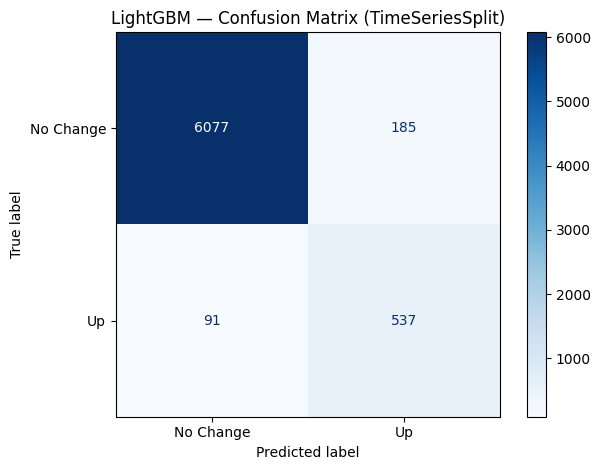

In [9]:
features = [
    "btc_to_threshold_pct", "btc_return_1m", "rolling_volatility_15m",
    "poly_lag_1", "poly_lag_3", "btc_lag_1", "yes_price"
]

df_model = df[features + ["target"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["target"]

# TimeSeriesSplit prevents data leakage
tscv = TimeSeriesSplit(n_splits=5)

all_preds = []
all_true  = []
all_probs = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    all_preds.extend(preds)
    all_true.extend(y_test)
    all_probs.extend(probs)

    fold_auc = roc_auc_score(y_test, probs)
    print(f"Fold {fold+1}: test={len(y_test)}, positives={y_test.sum()}, AUC={fold_auc:.3f}")

print("\n" + "=" * 50)
print(classification_report(all_true, all_preds, target_names=["No Change", "Up"]))

overall_auc   = roc_auc_score(all_true, all_probs)
avg_precision = average_precision_score(all_true, all_probs)
print(f"AUC-ROC : {overall_auc:.4f}  (0.50 = random, 1.00 = perfect)")
print(f"PR-AUC  : {avg_precision:.4f}")

# Confusion matrix
cm   = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Change", "Up"])
disp.plot(cmap="Blues")
plt.title("LightGBM — Confusion Matrix (TimeSeriesSplit)")
plt.tight_layout()
plt.savefig("data/processed/plot_confusion_matrix.png", dpi=150)
plt.show()


Best threshold : 0.47
Best F1 (Up)   : 0.7962
Best F1 (Macro): 0.8869


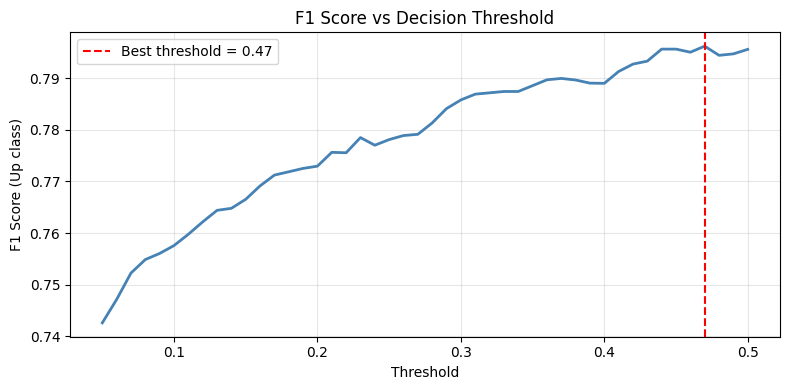

Classification Report at threshold=0.47
              precision    recall  f1-score   support

   No Change       0.99      0.97      0.98      6262
          Up       0.74      0.86      0.80       628

    accuracy                           0.96      6890
   macro avg       0.86      0.92      0.89      6890
weighted avg       0.96      0.96      0.96      6890



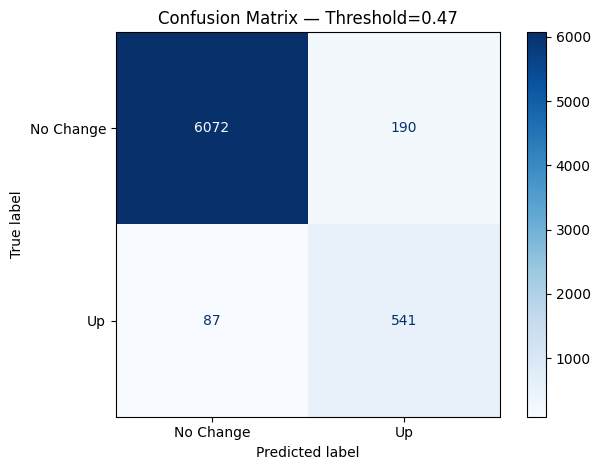

In [11]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Test every threshold from 0.05 to 0.50 and find best F1 for minority class
thresholds = np.arange(0.05, 0.51, 0.01)
results = []

for t in thresholds:
    preds_t = (np.array(all_probs) >= t).astype(int)
    f1_up   = f1_score(all_true, preds_t, pos_label=1, zero_division=0)
    f1_mac  = f1_score(all_true, preds_t, average="macro", zero_division=0)
    results.append((t, f1_up, f1_mac))

results = sorted(results, key=lambda x: x[1], reverse=True)
best_t, best_f1_up, best_f1_mac = results[0]
print(f"Best threshold : {best_t:.2f}")
print(f"Best F1 (Up)   : {best_f1_up:.4f}")
print(f"Best F1 (Macro): {best_f1_mac:.4f}")

# F1 vs threshold plot
ts  = [r[0] for r in sorted(results, key=lambda x: x[0])]
f1s = [r[1] for r in sorted(results, key=lambda x: x[0])]

plt.figure(figsize=(8, 4))
plt.plot(ts, f1s, color="steelblue", lw=2)
plt.axvline(best_t, color="red", linestyle="--", label=f"Best threshold = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score (Up class)")
plt.title("F1 Score vs Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_threshold_f1.png", dpi=150)
plt.show()

# Classification report at best threshold
preds_best = (np.array(all_probs) >= best_t).astype(int)
print("" + "=" * 50)
print(f"Classification Report at threshold={best_t:.2f}")
print("=" * 50)
print(classification_report(all_true, preds_best, target_names=["No Change", "Up"]))

# Confusion matrix at best threshold
cm   = confusion_matrix(all_true, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Change", "Up"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — Threshold={best_t:.2f}")
plt.tight_layout()
plt.savefig("data/processed/plot_confusion_matrix_tuned.png", dpi=150)
plt.show()


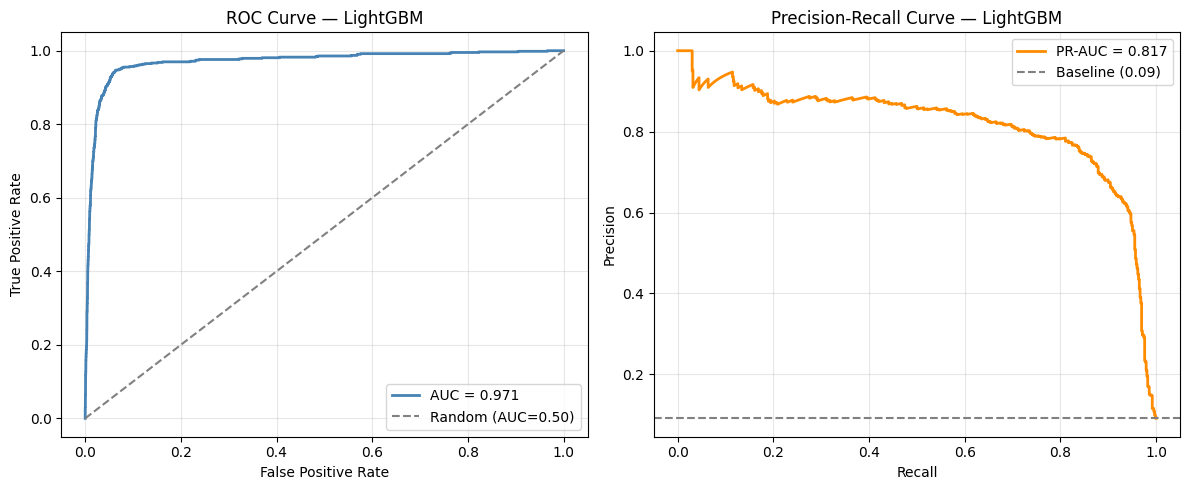

In [12]:
fpr, tpr, _         = roc_curve(all_true, all_probs)
pr_prec, pr_rec, _  = precision_recall_curve(all_true, all_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {overall_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Random (AUC=0.50)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — LightGBM")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
baseline = sum(all_true) / len(all_true)
axes[1].plot(pr_rec, pr_prec, color="darkorange", lw=2, label=f"PR-AUC = {avg_precision:.3f}")
axes[1].axhline(y=baseline, color="gray", linestyle="--", label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — LightGBM")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/plot_roc_pr.png", dpi=150)
plt.show()


Fold 1: test=1378, positives=64, AUC=0.696
Fold 2: test=1378, positives=132, AUC=0.576
Fold 3: test=1378, positives=122, AUC=0.694
Fold 4: test=1378, positives=133, AUC=0.718
Fold 5: test=1378, positives=177, AUC=0.784

EFFICIENCY MEASUREMENT — BTC-Only vs Full Model
Full model  AUC-ROC : 0.9705  PR-AUC: 0.8167
BTC-only    AUC-ROC : 0.6800  PR-AUC: 0.1569
AUC gap             : 0.2905

Interpretation: Polymarket moves largely independent of BTC signals.
=> Polymarket is INEFFICIENT — driven by own momentum, not BTC.


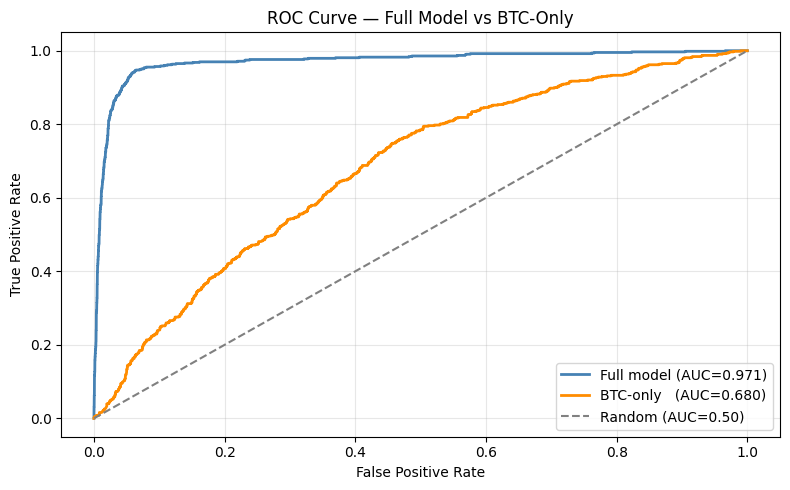

              precision    recall  f1-score   support

   No Change       0.93      0.85      0.88      6262
          Up       0.18      0.33      0.23       628

    accuracy                           0.80      6890
   macro avg       0.55      0.59      0.56      6890
weighted avg       0.86      0.80      0.83      6890



In [13]:
# ── BTC-Only Model — Efficiency Measurement ───────────────────────────────
# Remove all Polymarket history features. Only use BTC-derived signals.
# If AUC approaches full model -> BTC drives Polymarket (efficient).
# If AUC drops significantly  -> Polymarket moves independently (inefficient).

btc_features = [
    "btc_to_threshold_pct",
    "btc_return_1m",
    "btc_lag_1",
    "rolling_volatility_15m",
]

df_btc   = df[btc_features + ["target"]].dropna().reset_index(drop=True)
X_btc    = df_btc[btc_features]
y_btc    = df_btc["target"]

tscv_btc  = TimeSeriesSplit(n_splits=5)
btc_preds = []
btc_true  = []
btc_probs = []

for fold, (tr_idx, te_idx) in enumerate(tscv_btc.split(X_btc)):
    X_btc_tr, X_btc_te = X_btc.iloc[tr_idx], X_btc.iloc[te_idx]
    y_btc_tr, y_btc_te = y_btc.iloc[tr_idx], y_btc.iloc[te_idx]

    m_btc = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbose=-1
    )
    m_btc.fit(X_btc_tr, y_btc_tr)

    probs      = m_btc.predict_proba(X_btc_te)[:, 1]
    preds      = m_btc.predict(X_btc_te)
    fold_auc   = roc_auc_score(y_btc_te, probs)

    btc_preds.extend(preds)
    btc_true.extend(y_btc_te)
    btc_probs.extend(probs)
    print(f"Fold {fold+1}: test={len(y_btc_te)}, positives={y_btc_te.sum()}, AUC={fold_auc:.3f}")

btc_auc = roc_auc_score(btc_true, btc_probs)
btc_ap  = average_precision_score(btc_true, btc_probs)

print("\n" + "=" * 55)
print("EFFICIENCY MEASUREMENT — BTC-Only vs Full Model")
print("=" * 55)
print(f"Full model  AUC-ROC : {overall_auc:.4f}  PR-AUC: {avg_precision:.4f}")
print(f"BTC-only    AUC-ROC : {btc_auc:.4f}  PR-AUC: {btc_ap:.4f}")
print(f"AUC gap             : {overall_auc - btc_auc:.4f}")
print()
if overall_auc - btc_auc < 0.05:
    print("Interpretation: BTC features alone explain most of Polymarket movement.")
    print("=> Polymarket prices Bitcoin outcomes EFFICIENTLY.")
elif overall_auc - btc_auc < 0.15:
    print("Interpretation: BTC has meaningful but partial explanatory power.")
    print("=> Polymarket is PARTIALLY efficient.")
else:
    print("Interpretation: Polymarket moves largely independent of BTC signals.")
    print("=> Polymarket is INEFFICIENT — driven by own momentum, not BTC.")

# ROC curve comparison
fpr_btc, tpr_btc, _ = roc_curve(btc_true, btc_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr,     tpr,     color="steelblue",   lw=2, label=f"Full model (AUC={overall_auc:.3f})")
plt.plot(fpr_btc, tpr_btc, color="darkorange",  lw=2, label=f"BTC-only   (AUC={btc_auc:.3f})")
plt.plot([0,1],[0,1], "--", color="gray", label="Random (AUC=0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Full Model vs BTC-Only")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_roc_btconly.png", dpi=150)
plt.show()

print(classification_report(btc_true, btc_preds, target_names=["No Change", "Up"]))


In [ ]:
# ================================================================
# LAG MEASUREMENT — How long does Polymarket take to react to BTC?
# ================================================================
# Method: Cross-lag correlation
# For each market, correlate BTC signal at time t with
# Polymarket price at time t+lag (0..12 hours).
# Peak correlation lag = average Polymarket reaction delay.

from scipy.stats import pearsonr

MAX_LAG  = 12
lag_corrs = {lag: [] for lag in range(MAX_LAG + 1)}

for cid, grp in df.groupby('conditionId'):
    grp = grp.sort_values('timestamp').reset_index(drop=True)
    if len(grp) < 15:
        continue

    btc_signal = grp['btc_to_threshold_pct'].values
    poly_price = grp['yes_price'].values

    for lag in range(MAX_LAG + 1):
        x = btc_signal if lag == 0 else btc_signal[:-lag]
        y = poly_price  if lag == 0 else poly_price[lag:]
        if len(x) < 10:
            continue
        try:
            corr, _ = pearsonr(x, y)
            if not np.isnan(corr):
                lag_corrs[lag].append(corr)
        except Exception:
            pass

avg_corr = {lag: np.mean(vals) for lag, vals in lag_corrs.items() if vals}
best_lag = max(avg_corr, key=avg_corr.get)

print("Cross-lag correlation  BTC[t] vs Polymarket[t+lag]:")
for lag, corr in avg_corr.items():
    marker = " <-- PEAK" if lag == best_lag else ""
    print(f"  Lag {lag:2d}h: {corr:.4f}{marker}")

print(f"\nPeak correlation at lag : {best_lag} hour(s)")
print(f"=> Polymarket lags BTC by approximately {best_lag} hour(s)")

# Plot lag correlation curve
lags  = list(avg_corr.keys())
corrs = list(avg_corr.values())

plt.figure(figsize=(9, 4))
plt.plot(lags, corrs, "o-", color="steelblue", lw=2, markersize=6)
plt.axvline(best_lag, color='red', linestyle='--',
            label=f"Peak lag = {best_lag}h")
plt.xlabel("Lag (hours) — Polymarket measured this many hours after BTC")
plt.ylabel("Average Pearson Correlation")
plt.title("Lag Measurement: BTC[t] vs Polymarket[t + lag]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/plot_lag_correlation.png", dpi=150)
plt.show()

# ---- Disagreement Analysis ----------------------------------------
# When BTC is above threshold, yes_price should be > 0.5 (agree).
# When they disagree, Polymarket hasn't priced in BTC's move yet.

df['btc_above']  = (df['btc_to_threshold_pct'] > 0).astype(int)
df['poly_above'] = (df['yes_price'] > 0.5).astype(int)
df['disagree']   = (df['btc_above'] != df['poly_above']).astype(int)

total      = len(df)
disagreed  = df['disagree'].sum()
print(f"\nDisagreement Analysis:")
print(f"  Total observations : {total}")
print(f"  BTC vs Poly disagree: {disagreed} ({disagreed/total*100:.1f}%)")
print(f"  Agreement rate      : {(total-disagreed)/total*100:.1f}%")

# Disagreement rate by yes_price distance from 0.5
df['poly_certainty'] = (df['yes_price'] - 0.5).abs()
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
labels = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']
df['certainty_bin'] = pd.cut(df['poly_certainty'], bins=bins, labels=labels)
disagree_by_cert = df.groupby('certainty_bin', observed=True)['disagree'].mean() * 100

print("\nDisagreement rate by Polymarket certainty:")
print(disagree_by_cert.round(1).to_string())
print("(Low certainty = yes_price near 0.5 = uncertain market)")


In [14]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.shape)
print("SHAP values type :", type(shap_values))


SHAP values shape: (1378, 7)
SHAP values type : <class 'shap._explanation.Explanation'>


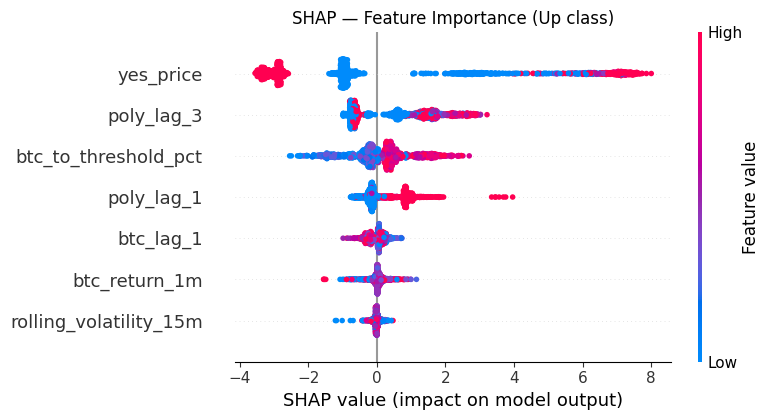

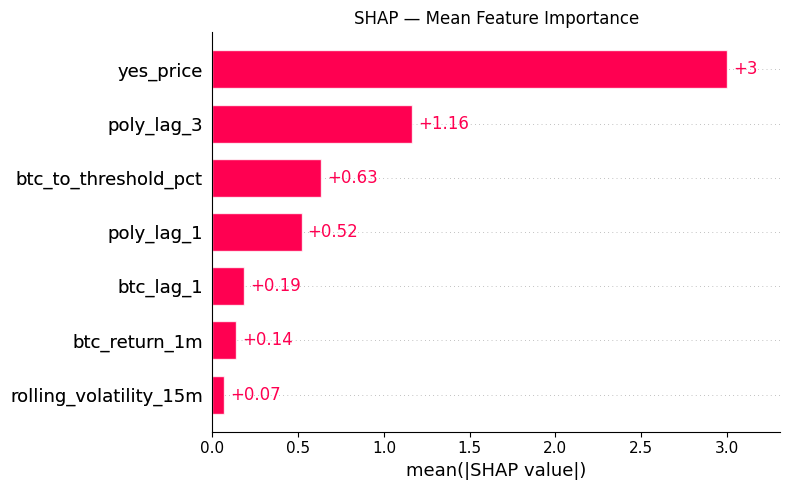

In [15]:
# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=7, show=False)
plt.title("SHAP — Feature Importance (Up class)")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot
shap.plots.bar(shap_values, max_display=7, show=False)
plt.title("SHAP — Mean Feature Importance")
plt.tight_layout()
plt.savefig("data/processed/plot_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
import subprocess, os
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")
os.chdir("/content/DSA-Project")

subprocess.run(["git", "config", "user.email", "kadirnsy@gmail.com"])
subprocess.run(["git", "config", "user.name",  "llelus"])
subprocess.run(["git", "pull", "--rebase", "origin", "main"])
subprocess.run(["git", "add", "data/processed/"])
subprocess.run(["git", "commit", "-m", "add: ML outputs — confusion matrix, ROC/PR curves, SHAP plots"])
subprocess.run(["git", "push", f"https://{token}@github.com/llelus/DSA-Project.git", "main"])
print("Done.")


Done.
